C:\Users\WenhaoLi\AppData\Local\Temp\ipykernel_18388\3998875963.py:14: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  train_images.append(torch.load(f"{DATA_PATH}/train_image

[tensor([[[0., 0., 0.,  ..., 0., 0., 0.],
         [0., 0., 0.,  ..., 0., 0., 0.],
         [0., 0., 0.,  ..., 0., 0., 0.],
         ...,
         [0., 0., 0.,  ..., 0., 0., 0.],
         [0., 0., 0.,  ..., 0., 0., 0.],
         [0., 0., 0.,  ..., 0., 0., 0.]],

        [[0., 0., 0.,  ..., 0., 0., 0.],
         [0., 0., 0.,  ..., 0., 0., 0.],
         [0., 0., 0.,  ..., 0., 0., 0.],
         ...,
         [0., 0., 0.,  ..., 0., 0., 0.],
         [0., 0., 0.,  ..., 0., 0., 0.],
         [0., 0., 0.,  ..., 0., 0., 0.]],

        [[0., 0., 0.,  ..., 0., 0., 0.],
         [0., 0., 0.,  ..., 0., 0., 0.],
         [0., 0., 0.,  ..., 0., 0., 0.],
         ...,
         [0., 0., 0.,  ..., 0., 0., 0.],
         [0., 0., 0.,  ..., 0., 0., 0.],
         [0., 0., 0.,  ..., 0., 0., 0.]],

        ...,

        [[0., 0., 0.,  ..., 0., 0., 0.],
         [0., 0., 0.,  ..., 0., 0., 0.],
         [0., 0., 0.,  ..., 0., 0., 0.],
         ...,
         [0., 0., 0.,  ..., 0., 0., 0.],
         [0., 0., 0.,

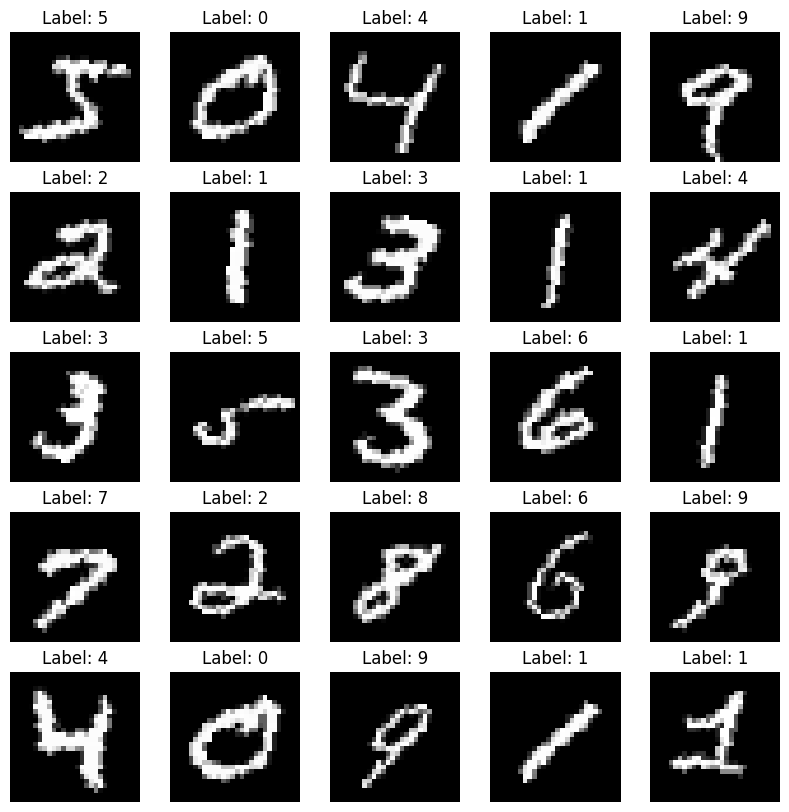

In [ ]:
from __future__ import annotations

import matplotlib.pyplot as plt  # only needed for plotting
import torch
from mpl_toolkits.axes_grid1 import ImageGrid  # only needed for plotting

DATA_PATH = "data/corruptmnist"


def corrupt_mnist() -> tuple[torch.utils.data.Dataset, torch.utils.data.Dataset]:
    """Return train and test dataloaders for corrupt MNIST."""
    train_images, train_target = [], []
    for i in range(6):
        train_images.append(torch.load(f"{DATA_PATH}/train_images_{i}.pt"))
        train_target.append(torch.load(f"{DATA_PATH}/train_target_{i}.pt"))
    
    train_images = torch.cat(train_images)
    train_target = torch.cat(train_target)

    test_images: torch.Tensor = torch.load(f"{DATA_PATH}/test_images.pt")
    test_target: torch.Tensor = torch.load(f"{DATA_PATH}/test_target.pt")

    train_images = train_images.unsqueeze(1).float()
    test_images = test_images.unsqueeze(1).float()
    train_target = train_target.long()
    test_target = test_target.long()

    train_set = torch.utils.data.TensorDataset(train_images, train_target)
    test_set = torch.utils.data.TensorDataset(test_images, test_target)

    return train_set, test_set


def show_image_and_target(images: torch.Tensor, target: torch.Tensor) -> None:
    """Plot images and their labels in a grid."""
    row_col = int(len(images) ** 0.5)
    fig = plt.figure(figsize=(10.0, 10.0))
    grid = ImageGrid(fig, 111, nrows_ncols=(row_col, row_col), axes_pad=0.3)
    for ax, im, label in zip(grid, images, target):
        ax.imshow(im.squeeze(), cmap="gray")
        ax.set_title(f"Label: {label.item()}")
        ax.axis("off")
    plt.show()


if __name__ == "__main__":
    train_set, test_set = corrupt_mnist()
    print(f"Size of training set: {len(train_set)}")
    print(f"Size of test set: {len(test_set)}")
    print(f"Shape of a training point {(train_set[0][0].shape, train_set[0][1].shape)}")
    print(f"Shape of a test point {(test_set[0][0].shape, test_set[0][1].shape)}")
    show_image_and_target(train_set.tensors[0][:25], train_set.tensors[1][:25])
